In [367]:
from spar import basicFunction, readBasicFunctions, kineticMapping, potentialMapping, externalMapping
import importlib

importlib.reload(spar)
import numpy as np
import re
import matplotlib.pyplot as plt
%matplotlib inline

### KEO Demo
Below we illustrate how SPAR is used to return the $G$ matrix and pseudopotential $U$ of an A2BC type molecule at a single point such that it might be evaluated using multi-dimensional quadrature. 

We highlight how the same checkpoint file and basic functions are usable for both H2CS and H2CO, merely by changing the masses and as such is valid for all molecules of the same structure. 

In [73]:
toRadians = np.pi/180.0

# Case of H2CS
masses = np.array([12.00000000, 31.9720707, 1.00782503223, 1.00782503223])
# Geometry we wish to evaluate KEO at for quadrature (single-point calculation)
internalCoordinates = np.array([1.608952, 1.086848, 1.086848, 121.750*toRadians, 121.750*toRadians, np.pi])

# Read basic functions for A2BC type molecule
basicFunctions = readBasicFunctions("KEO/A2BC/combination.chk")

# Read KEO checkpoint
keoMapping = kineticMapping("KEO/A2BC/kinetic.chk")
# Evaluate returns specified component component
keoMapping.evaluate("gvib", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("grot", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("gcor", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("pseudo", basicFunctions, internalCoordinates, masses)

# To switch to H2CO all we need is to change masses
masses = np.array([12.00000000, 15.99491463, 1.00782503223, 1.00782503223])
# Geometry we wish to evaluate KEO at for quadrature (single-point calculation)
internalCoordinates = np.array([1.203374200, 1.103774652, 1.103774652, 2.12658330381800, 2.12658330381800, np.pi])
keoMapping.evaluate("gvib", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("grot", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("gcor", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("pseudo", basicFunctions, internalCoordinates, masses) 

np.float64(-16.12726266663172)

### Potential: AMES example
Below we highlight how following in the same construct we can represent a variety of algebriac forms in SPAR format. The example here is the carbon disulphide potential from AMES (Huang et al, 2024). The potential consists of both short- and long-range parts, including damping terms. 

Text(0, 0.5, 'E, cm$^{-1}$')

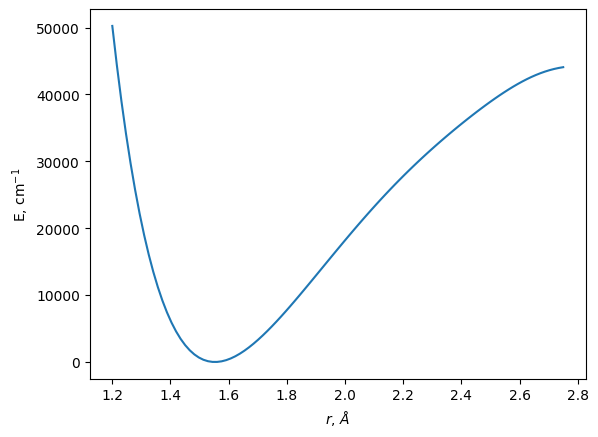

In [351]:
# AMES potential for CS2 Huang et al 2024
internalCoordinates = np.array([1.55275, 1.55275, np.pi])
basicFunctions = readBasicFunctions("Potentials/CS2/combination.chk")
pesMapping = potentialMapping("Potentials/CS2/potential.chk")

rGrid = np.linspace(1.2, 2.75, 100)
potentialGrid = np.zeros(len(rGrid))
for i in range(len(rGrid)):
    internalCoordinates[0] = rGrid[i]
    potentialGrid[i] = pesMapping.evaluate(basicFunctions, internalCoordinates)

plt.plot(rGrid, potentialGrid)
plt.xlabel(r"$r$, $\AA$")
plt.ylabel(r"E, cm$^{-1}$")

### External block: OTY7 dipole LiOH
Below we present the example of the OTY7 dipole for LiOH (Owens et al, 2024). This is given as an ``external.chk`` file and is read analogously to the potential with the key difference being that the structure is vectorised with three components. Alternatively, this structure can be used to read in derivatives of symmetry-adapted potentials, which is necessary for empirical refinement, with each component corresponding to a symmetry independent parameter.

Text(0, 0.5, '$\\mu_x$, Debye')

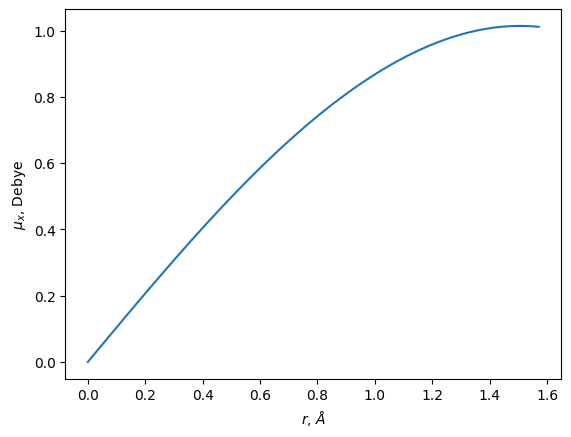

In [382]:
# OTY7 Dipole Moment surface
internalCoordinates = np.array([1.6000, 0.9478, 0.0])
basicFunctions = readBasicFunctions("External/Dipoles/LiOH/combination.chk")
dipoleMapping = externalMapping("External/Dipoles/LiOH/external.chk")

alphaGrid = np.linspace(0, np.pi/2, 100)
dipoleGrid = np.zeros(len(rGrid))
for i in range(len(rGrid)):
    internalCoordinates[2] = alphaGrid[i]
    dipoleGrid[i] = dipoleMapping.evaluate(basicFunctions, internalCoordinates)[0]

plt.plot(alphaGrid, dipoleGrid)
plt.xlabel(r"$r$, $\AA$")
plt.ylabel(r"$\mu_x$, Debye")